# PWM-synchronized current sampling — crest vs valley on the low-side shunts

Illustrates the two current-sampling paths against each other on real load
current:

- **Injected path** — TIM1 OC4 (PWM2, CCR4 = 3528 of ARR 3600) fires TRGO2
  once per 20 kHz period, ~2 µs before the counter crest: **both** low-side
  FETs freewheel there, so both conducting shunts read the true winding
  current (opposite signs through the two legs).
- **Regular path** — the 1 ms polled sequence. The tick and TIM1 are
  phase-locked (exactly 20 periods/tick), so it samples a **fixed instant in
  the valley region**, where the PWM'd leg's current is in its high-side FET
  (its shunt reads nothing) and only the tied-low leg conducts.

This supersedes the `(1-duty)*I` model in `stall_r_analysis.ipynb` — that
capture predates the true-20 kHz timer fix, when the unlocked clocks made
regular sampling effectively random-phase.

**Input:** `capture_20260821_204134.csv` — six-step spin with two hand-braked
intervals (~0.3 A). Sign convention as decoded by the firmware: tied/return
leg positive, PWM'd source leg negative at the crest. Run with the repo venv
kernel (`.venv`).

In [1]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CSV = Path("capture_20260821_204134.csv")
PHASES = ["u", "v", "w"]

raw = defaultdict(list)
with open(CSV) as f:
    for row in csv.DictReader(f):
        raw[row["signalName"].split("/")[-1]].append((int(row["t"]), float(row["value"])))

FAST = ["motor_angle", "mc_magdeg", "inj_cb",
        "phase_u_i", "phase_v_i", "phase_w_i", "inj_u_i", "inj_v_i", "inj_w_i"]
n = min(len(raw[s]) for s in FAST)
t_ms = np.array([t for t, _ in raw["mc_magdeg"]])[:n]
tb = (t_ms - t_ms[0]) * 1e-3
sig = {s: np.array([v for _, v in raw[s]])[:n] for s in FAST}

bt = np.array([t for t, _ in raw["mc_bridge_on"]])
bv = np.array([v for _, v in raw["mc_bridge_on"]])
edges = np.flatnonzero(np.diff(bv) != 0) + 1
t_on = (bt[edges[bv[edges] == 1][0]] - t_ms[0]) * 1e-3
t_off = (bt[edges[bv[edges] == 0][0]] - t_ms[0]) * 1e-3

I_reg = np.stack([sig[f"phase_{p}_i"] for p in PHASES])
I_inj = np.stack([sig[f"inj_{p}_i"] for p in PHASES])
print(f"{n} aligned samples over {tb[-1]:.1f} s; bridge on {t_on:.1f}..{t_off:.1f} s")

12948 aligned samples over 25.9 s; bridge on 2.3..24.3 s


## Where each path samples the PWM period

One 50 µs center-aligned period at the braked operating point. The injected
trigger lands in the freewheel window for any duty below CCR4/ARR = 0.98 —
the firmware's 0.9 duty clamp keeps that margin.

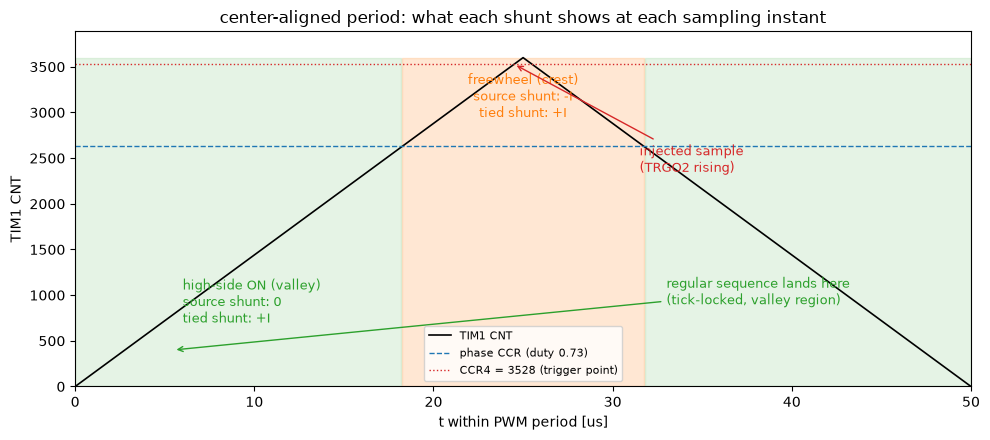

In [2]:
ARR, CCR4, DUTY = 3600, 3528, 0.73
PER_US = 50.0
x = np.linspace(0.0, PER_US, 1201)
cnt = np.where(x <= PER_US / 2, x, PER_US - x) * (2 * ARR / PER_US)
ccr = DUTY * ARR
trig_us = (CCR4 / ARR) * (PER_US / 2)   # rising crossing, up-count

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x, cnt, "k-", lw=1.2, label="TIM1 CNT")
ax.axhline(ccr, color="tab:blue", lw=1.0, ls="--", label=f"phase CCR (duty {DUTY})")
ax.axhline(CCR4, color="tab:red", lw=1.0, ls=":", label="CCR4 = 3528 (trigger point)")
ax.fill_between(x, 0, ARR, where=cnt < ccr, color="tab:green", alpha=0.12)
ax.fill_between(x, 0, ARR, where=cnt >= ccr, color="tab:orange", alpha=0.18)
ax.annotate("high-side ON (valley)" + chr(10) + "source shunt: 0" + chr(10) + "tied shunt: +I",
            xy=(6, 700), fontsize=9, color="tab:green")
ax.annotate("freewheel (crest)" + chr(10) + "source shunt: -I" + chr(10) + "tied shunt: +I",
            xy=(25.0, 2950), fontsize=9, color="tab:orange", ha="center")
ax.annotate("injected sample" + chr(10) + "(TRGO2 rising)", xy=(trig_us, CCR4),
            xytext=(31.5, 2350), fontsize=9, color="tab:red",
            arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.annotate("regular sequence lands here" + chr(10) + "(tick-locked, valley region)", xy=(5.5, 400),
            xytext=(33, 900), fontsize=9, color="tab:green",
            arrowprops=dict(arrowstyle="->", color="tab:green"))
ax.set_xlabel("t within PWM period [us]")
ax.set_ylabel("TIM1 CNT")
ax.set_xlim(0, PER_US)
ax.set_ylim(0, ARR * 1.08)
ax.legend(loc="lower center", fontsize=8)
ax.set_title("center-aligned period: what each shunt shows at each sampling instant")
fig.tight_layout()

## Raw capture

Injected vs regular phase currents, the braked intervals, and the injected
completion cadence (exactly 20 kHz while the bridge runs).

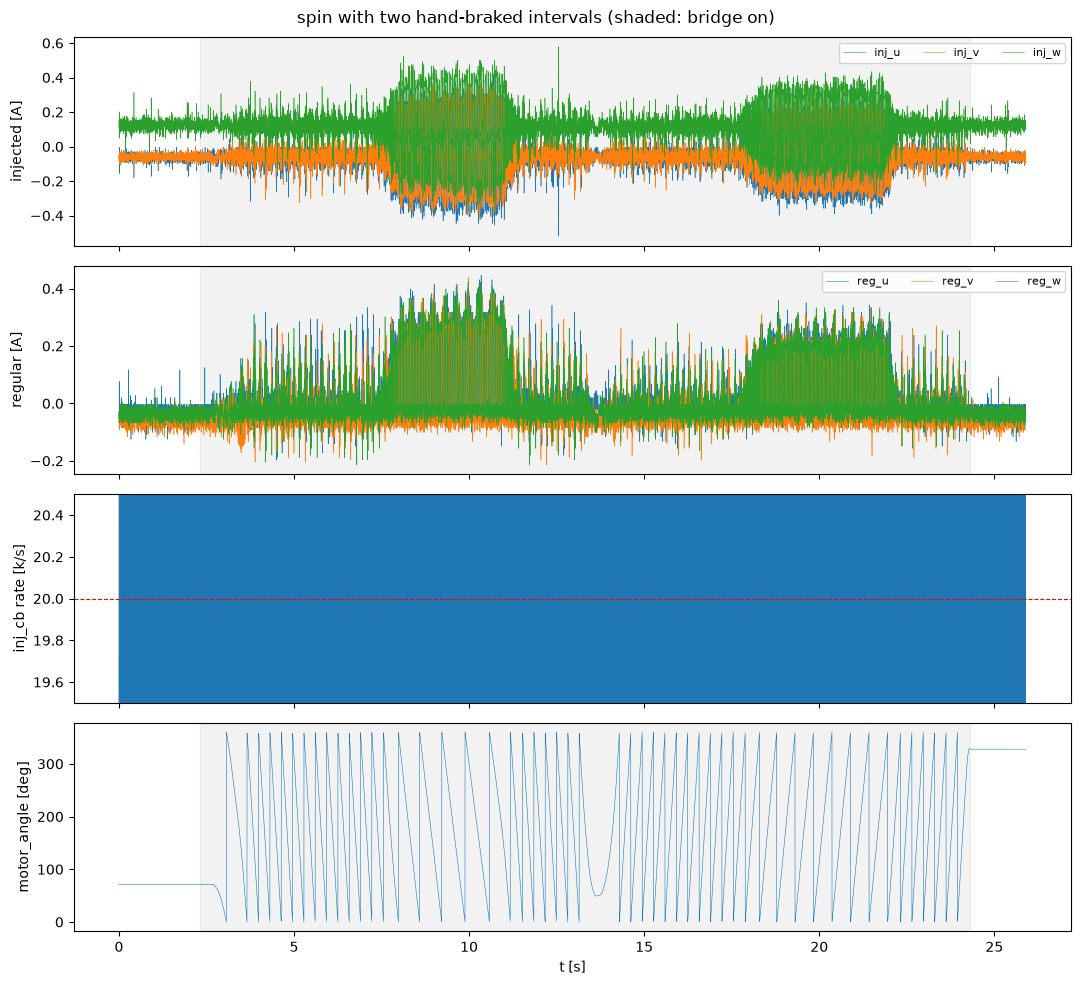

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for k, p in enumerate(PHASES):
    axes[0].plot(tb, I_inj[k], lw=0.4, label=f"inj_{p}")
    axes[1].plot(tb, I_reg[k], lw=0.4, label=f"reg_{p}")
axes[0].set_ylabel("injected [A]")
axes[1].set_ylabel("regular [A]")
rate = np.diff(sig["inj_cb"]) / np.diff(tb)
axes[2].plot(tb[1:], rate * 1e-3, lw=0.5)
axes[2].axhline(20.0, color="r", lw=0.8, ls="--")
axes[2].set_ylabel("inj_cb rate [k/s]")
axes[2].set_ylim(19.5, 20.5)
axes[3].plot(tb, sig["motor_angle"], lw=0.4)
axes[3].set_ylabel("motor_angle [deg]")
axes[3].set_xlabel("t [s]")
for ax in axes:
    ax.axvspan(t_on, t_off, color="k", alpha=0.05)
axes[0].legend(ncol=3, fontsize=8)
axes[1].legend(ncol=3, fontsize=8)
fig.suptitle("spin with two hand-braked intervals (shaded: bridge on)")
fig.tight_layout()

## Sensor offsets from the bridge-dark lead-in

No winding current with the bridge dark, so each channel's mean there is its
offset. `inj_w` is derived in firmware as `-(u+v)`, so its offset is the
negated sum of the other two — visible below.

In [4]:
rest = tb < (t_on - 0.2)
off_reg = I_reg[:, rest].mean(axis=1)
off_inj = I_inj[:, rest].mean(axis=1)
Ir = I_reg - off_reg[:, None]
Ii = I_inj - off_inj[:, None]
for k, p in enumerate(PHASES):
    print(f"phase {p}: reg offset {off_reg[k]*1e3:+6.1f} mA   inj offset {off_inj[k]*1e3:+6.1f} mA")

phase u: reg offset  -27.6 mA   inj offset  -63.2 mA
phase v: reg offset  -61.9 mA   inj offset  -60.7 mA
phase w: reg offset  -37.4 mA   inj offset +124.4 mA


## Leg roles and the crest-vs-valley signature

Six-step: at any instant one phase is PWM'd (source), one is tied low
(return), one floats. Roles are assigned per sample from the injected trio
(tied = most positive, source = most negative — commutation-boundary-proof),
over the strongly braked samples. The signature:

| leg | injected (crest) | regular (valley) |
|---|---|---|
| source | **-I** (freewheel through its shunt) | **~0** (current in high-side FET) |
| tied | **+I** | **+I** (conducts full-time) |
| float | 0 | 0 |

Only a correctly-phased crest sample can see the source leg's current at
all — that column is the proof the OC4/TRGO2 chain samples where intended.

braked samples: 2069 of 10999 spinning
source: inj median -0.269 A   reg median +0.002 A
  tied: inj median +0.295 A   reg median +0.299 A
 float: inj median -0.016 A   reg median +0.002 A


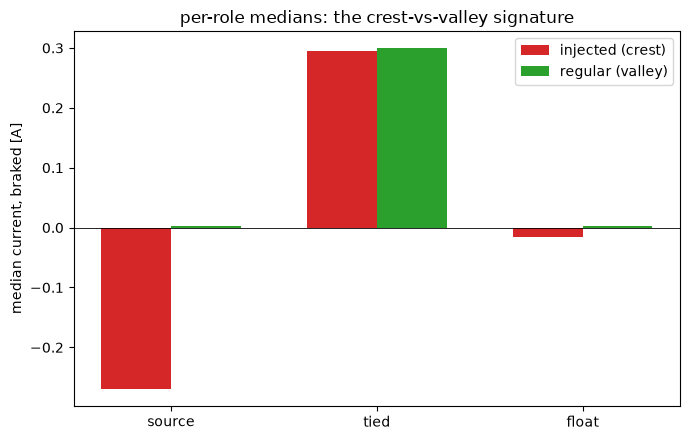

In [5]:
sector = (sig["mc_magdeg"] // 60).astype(int) % 6
spin = (tb > t_on) & (tb < t_off)
braked = spin & (np.abs(Ii).max(axis=0) > 0.25)
print(f"braked samples: {braked.sum()} of {spin.sum()} spinning")

role_idx = {"source": Ii.argmin(axis=0), "tied": Ii.argmax(axis=0)}
role_idx["float"] = 3 - role_idx["source"] - role_idx["tied"]

cols = np.arange(n)
table = []
for r in ("source", "tied", "float"):
    ii = Ii[role_idx[r], cols][braked]
    rr = Ir[role_idx[r], cols][braked]
    table.append((r, np.median(ii), np.median(rr)))
    print(f"{r:>6}: inj median {np.median(ii):+.3f} A   reg median {np.median(rr):+.3f} A")

fig, ax = plt.subplots(figsize=(7, 4.5))
xpos = np.arange(3)
ax.bar(xpos - 0.17, [t[1] for t in table], 0.34, label="injected (crest)", color="tab:red")
ax.bar(xpos + 0.17, [t[2] for t in table], 0.34, label="regular (valley)", color="tab:green")
ax.set_xticks(xpos)
ax.set_xticklabels([t[0] for t in table])
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("median current, braked [A]")
ax.legend()
ax.set_title("per-role medians: the crest-vs-valley signature")
fig.tight_layout()

## Per-leg distributions, braked

Left: the source leg — regular piles at zero (its shunt idle at the valley
instant) while injected reads the full freewheel current. Right: the tied
leg — both paths read the full return current; the small gap is ripple phase
between the two instants.

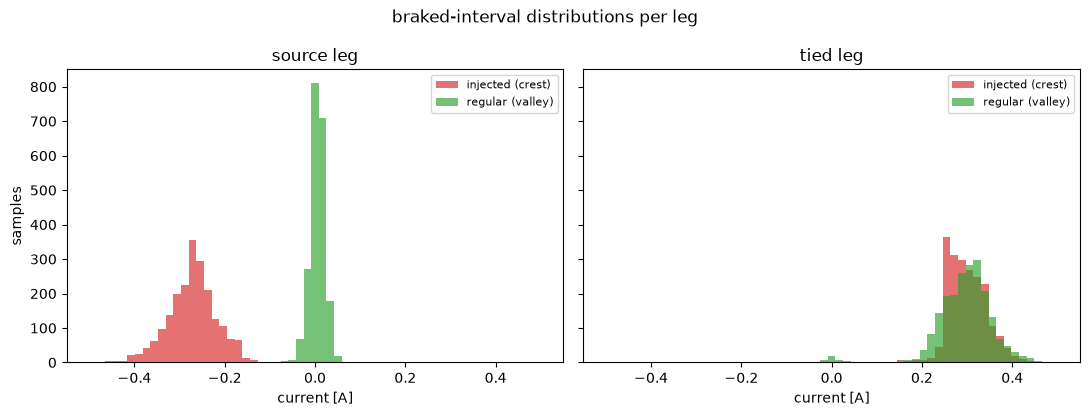

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
bins = np.linspace(-0.5, 0.5, 60)
for ax, r in zip(axes, ("source", "tied")):
    ii = Ii[role_idx[r], cols][braked]
    rr = Ir[role_idx[r], cols][braked]
    ax.hist(ii, bins=bins, alpha=0.65, color="tab:red", label="injected (crest)")
    ax.hist(rr, bins=bins, alpha=0.65, color="tab:green", label="regular (valley)")
    ax.set_title(f"{r} leg")
    ax.set_xlabel("current [A]")
    ax.legend(fontsize=8)
axes[0].set_ylabel("samples")
fig.suptitle("braked-interval distributions per leg")
fig.tight_layout()

## Freewheel loop equality

At the crest instant the same loop current passes through both conducting
shunts, so |source| and |tied| must match sector-by-sector — including the
sectors where one of them is the derived `w = -(u+v)`: the two-shunt
derivation checked against the loop.

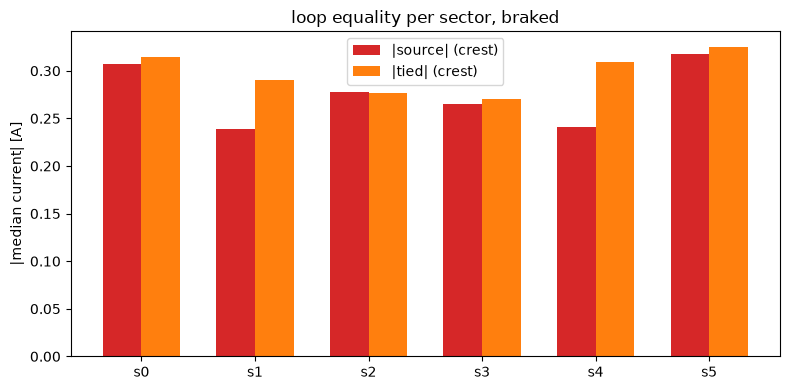

In [7]:
labels, src_m, tied_m = [], [], []
src_v = Ii[role_idx["source"], cols]
tied_v = Ii[role_idx["tied"], cols]
for s in range(6):
    m = braked & (sector == s)
    if m.sum() < 50:
        continue
    labels.append(f"s{s}")
    src_m.append(-np.median(src_v[m]))
    tied_m.append(np.median(tied_v[m]))
fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(labels))
ax.bar(xpos - 0.17, src_m, 0.34, label="|source| (crest)", color="tab:red")
ax.bar(xpos + 0.17, tied_m, 0.34, label="|tied| (crest)", color="tab:orange")
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel("|median current| [A]")
ax.legend()
ax.set_title("loop equality per sector, braked")
fig.tight_layout()

## Cadence

Least-squares slope of the completion counter against board time over the
bridge-on window — the injected chain's 20 kHz, exact under load. (At idle
the slope reads ~0.5% low: an ISR-latency coalescing effect at rest,
backlogged separately; not a trigger-chain property.)

In [8]:
m = spin
A = np.vstack([tb[m], np.ones(m.sum())]).T
slope = np.linalg.lstsq(A, sig["inj_cb"][m], rcond=None)[0][0]
print(f"inj_cb slope, bridge on: {slope:.1f}/s  (target 20000, err {100*(slope-20000)/20000:+.3f}%)")

inj_cb slope, bridge on: 20000.0/s  (target 20000, err -0.000%)


## Conclusions

- The injected (crest) path reads true instantaneous winding current on both
  conducting legs — it is the current sense for the control loop.
- The regular path is valley-locked, not duty-weighted: it reads zero on the
  PWM'd leg and full current on the tied leg. Keep it as a diagnostic
  cross-check only, with that model.
- Derived `w = -(u+v)` holds against the loop across sectors: the two-shunt
  plan stands; W's own shunt stays a regular-path diagnostic.
- These distributions are the bench twin for the stage-6 SIL fine-grid
  asserts.